# Naive Bayes Classification using spam.csv

## Simple English: What is Naive Bayes?
- Naive Bayes is a fast text classification algorithm.
- It uses probability to decide the class (spam or ham).
- It assumes words are independent (this is the "naive" part).

In simple English: it checks which words are common in spam messages and which are common in normal messages, then predicts based on that.

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

## Step 2: Load Dataset

In [3]:
df = pd.read_csv('spam.csv', encoding='latin-1')
print('Original shape:', df.shape)
display(df.head())

Original shape: (5572, 5)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## Step 3: Data Cleaning and Preprocessing
We keep only useful columns:
- `v1`: label (ham/spam)
- `v2`: message text

In [ ]:
# Keep relevant columns and rename
df = df[['v1', 'v2']].copy()
df.columns = ['label', 'message']

# Remove any missing rows if present
df.dropna(inplace=True)

# Encode labels: ham -> 0, spam -> 1
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

print('Cleaned shape:', df.shape)
display(df.head())
print('\nClass distribution:')
print(df['label'].value_counts())

Cleaned shape: (5572, 3)


,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0



Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


## Step 4: Train-Test Split

In [5]:
X = df['message']
y = df['label_num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training samples:', len(X_train))
print('Testing samples:', len(X_test))

Training samples: 4457
Testing samples: 1115


## Step 5: Build Pipeline (TF-IDF + Naive Bayes)
- TF-IDF converts text to numeric features
- MultinomialNB is the Naive Bayes model for word counts/frequencies

## Step 5A: Vectorizers in Simple English

A machine learning model cannot read raw text directly, so we convert text into numbers.

Common vectorizers:
- **CountVectorizer**: Counts how many times each word appears in a message.
- **TfidfVectorizer**: Uses counts, but gives less weight to very common words and more weight to informative words.
- **HashingVectorizer**: Very fast and memory-friendly; maps words into fixed-size numeric buckets.

Why we use **TfidfVectorizer** here:
- Spam detection depends on informative words.
- TF-IDF often performs better than plain counts for text classification.

In [6]:
nb_pipeline = Pipeline(steps=[
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=5000)),
    ('nb', MultinomialNB(alpha=1.0))
])

## Step 6: Train and Predict

In [7]:
nb_pipeline.fit(X_train, y_train)
y_pred = nb_pipeline.predict(X_test)

print('First 10 predictions:', y_pred[:10])

First 10 predictions: [0 0 0 1 0 0 0 0 0 0]


## Step 7: Important Scores
- Accuracy: overall correct predictions
- Precision: out of predicted spam, how many are truly spam
- Recall: out of actual spam, how many are found
- F1-score: balance of precision and recall

In [8]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

scores_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1'],
    'Value': [acc, prec, rec, f1]
})

display(scores_df)
print(f'Accuracy : {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall   : {rec:.4f}')
print(f'F1 Score : {f1:.4f}')

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))

,Metric,Value
0,Accuracy,0.972197
1,Precision,0.991667
2,Recall,0.798658
3,F1,0.884758


Accuracy : 0.9722
Precision: 0.9917
Recall   : 0.7987
F1 Score : 0.8848

Classification Report:
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       966
        spam       0.99      0.80      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115



## Step 8: Graphs

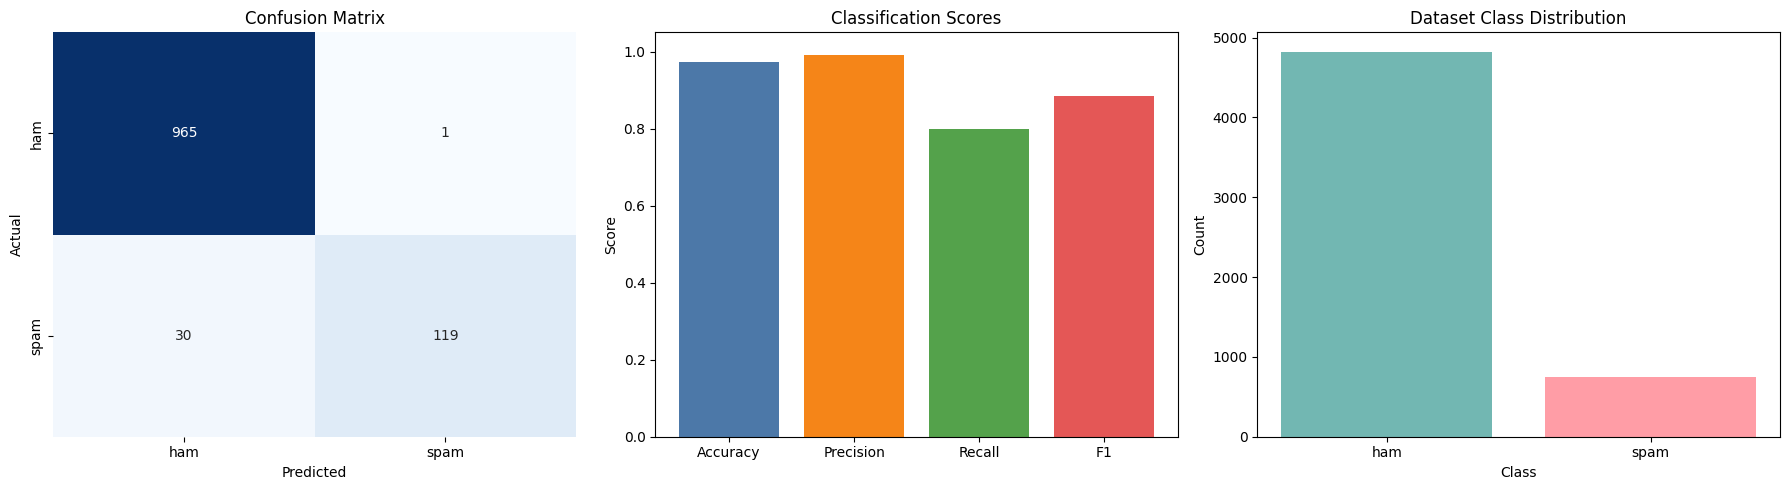

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticklabels(['ham', 'spam'])
axes[0].set_yticklabels(['ham', 'spam'])

# 2) Important scores bar chart
axes[1].bar(scores_df['Metric'], scores_df['Value'], color=['#4c78a8', '#f58518', '#54a24b', '#e45756'])
axes[1].set_title('Classification Scores')
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel('Score')

# 3) Class distribution
class_counts = df['label'].value_counts()
axes[2].bar(class_counts.index, class_counts.values, color=['#72b7b2', '#ff9da6'])
axes[2].set_title('Dataset Class Distribution')
axes[2].set_xlabel('Class')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

## Step 9: Compare Actual vs Predicted Labels

In [10]:
label_map = {0: 'ham', 1: 'spam'}
result_df = pd.DataFrame({
    'Message': X_test.values[:10],
    'Actual': [label_map[v] for v in y_test.values[:10]],
    'Predicted': [label_map[v] for v in y_pred[:10]]
})
display(result_df)

,Message,Actual,Predicted
0,"Oh right, ok. I'll make sure that i do loads o...",ham,ham
1,I am in tirupur. call you da.,ham,ham
2,No that just means you have a fat head,ham,ham
3,"You have won ?1,000 cash or a ?2,000 prize! To...",spam,spam
4,Come aftr &lt;DECIMAL&gt; ..now i m cleaning ...,ham,ham
5,Friendship poem: Dear O Dear U R Not Near But ...,ham,ham
6,Wot about on wed nite I am 3 then but only til 9!,ham,ham
7,Dont talk to him ever ok its my word.,ham,ham
8,Congrats kano..whr s the treat maga?,ham,ham
9,Eh u remember how 2 spell his name... Yes i di...,ham,ham


## Simple English Summary
- We cleaned spam.csv and used text + label columns.
- TF-IDF converted text into numbers.
- Naive Bayes predicted spam/ham classes.
- Accuracy, Precision, Recall, and F1 showed model quality.
- Graphs made performance and class balance easy to understand.

In [32]:

s = "hello, I have a great offer for you! Click here to win a free iPhone!"
predictions = "spam" if nb_pipeline.predict([s])[0] == 1 else "not spam"
print(f'The message: "{s}" is predicted as: {predictions}')
print("the probability of being spam:", nb_pipeline.predict_proba([s])[0][1])

The message: "hello, I have a great offer for you! Click here to win a free iPhone!" is predicted as: not spam
the probability of being spam: 0.30649820655357324


In [33]:
df = pd.read_csv('spam.csv', encoding='latin-1')
print('Original shape:', df.shape)
display(df.head())

Original shape: (5572, 5)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [34]:
# Keep relevant columns and rename
df = df[['v1', 'v2']].copy()
df.columns = ['label', 'message']

# Remove any missing rows if present
df.dropna(inplace=True)

# Encode labels: ham -> 0, spam -> 1
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

print('Cleaned shape:', df.shape)
display(df.head())
print('\nClass distribution:')
print(df['label'].value_counts())

Cleaned shape: (5572, 3)


,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0



Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


In [35]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X = df['message']
X_vectorized = vectorizer.fit_transform(X)
print('Vectorized shape:', X_vectorized.shape)

Vectorized shape: (5572, 5000)


In [40]:
X_vectorized_df = pd.DataFrame(X_vectorized.toarray())
X_vectorized_df.head()

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [41]:
X_vectorized_df = pd.DataFrame(X_vectorized.toarray(), columns=vectorizer.get_feature_names_out())
X_vectorized_df.to_csv('vectorized_messages.csv', index=False)